# Test Hybrid Approach

**Hybrid = Analytical jinc² sampling + Fraunhofer propagation**

Combines:
1. ✓ No FFT discretization (analytical sampling)
2. ✓ Correct wavelength dependence (Fraunhofer formula)

Should give the best of both worlds!

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import j1

from monte_carlo.angular_spectrum import AngularSpectrumSimulator
from monte_carlo.angular_spectrum_hybrid import AngularSpectrumHybrid
from monte_carlo.core import ApertureSimulator
from monte_carlo import metrics

sns.set_theme(style="whitegrid", font_scale=1.3)

import os
output_dir = '../data/hybrid_test'
os.makedirs(output_dir, exist_ok=True)

## Setup

In [2]:
n_photons = 1000000
wavelength = 0.6328  # microns
focal_length = 10.0  # mm
NA = 0.1
n_medium = 1.0
random_seed = 42
fft_size = 2048

airy_radius = 1.22 * wavelength / NA

print(f"Parameters:")
print(f"  N photons: {n_photons:,}")
print(f"  Wavelength: {wavelength} μm")
print(f"  NA: {NA}")
print(f"  Airy radius: {airy_radius:.4f} μm")

Parameters:
  N photons: 1,000,000
  Wavelength: 0.6328 μm
  NA: 0.1
  Airy radius: 7.7202 μm


## Run All Three Approaches

In [3]:
print("1. FFT + Fraunhofer (angular_spectrum.py)...")
sim_fft = AngularSpectrumSimulator(
    n_photons=n_photons,
    wavelength=wavelength,
    focal_length=focal_length,
    numerical_aperture=NA,
    n_medium=n_medium,
    fft_size=fft_size,
    random_seed=random_seed
)
results_fft = sim_fft.propagate()
x_fft, y_fft, _ = results_fft['focal_positions']
print(f"   Got {len(x_fft):,} photons")

print("\n2. Analytical + Fraunhofer (HYBRID)...")
sim_hybrid = AngularSpectrumHybrid(
    n_photons=n_photons,
    wavelength=wavelength,
    focal_length=focal_length,
    numerical_aperture=NA,
    n_medium=n_medium,
    random_seed=random_seed
)
results_hybrid = sim_hybrid.propagate()
x_hybrid, y_hybrid, _ = results_hybrid['focal_positions']
print(f"   Got {len(x_hybrid):,} photons")

print("\n3. Aperture Sampling (reference)...")
sim_aperture = ApertureSimulator(
    n_photons=n_photons,
    wavelength=wavelength,
    focal_length=focal_length,
    numerical_aperture=NA,
    n_medium=n_medium,
    random_seed=random_seed
)
results_aperture = sim_aperture.propagate()
x_aperture, y_aperture, _ = results_aperture['focal_positions']
print(f"   Got {len(x_aperture):,} photons")

1. FFT + Fraunhofer (angular_spectrum.py)...


   Got 1,000,000 photons

2. Analytical + Fraunhofer (HYBRID)...


   Got 1,000,000 photons

3. Aperture Sampling (reference)...


   Got 1,000,000 photons


## Compare Radial Profiles

In [4]:
plot_range = 2 * airy_radius
n_bins = 300
r_bins = np.linspace(0, plot_range, n_bins)
r_centers = (r_bins[:-1] + r_bins[1:]) / 2
bin_areas = np.pi * (r_bins[1:]**2 - r_bins[:-1]**2)

# Theory
k_theory = 2 * np.pi * NA / wavelength
kr_theory = k_theory * r_centers
airy_theory = np.ones_like(kr_theory)
nonzero = kr_theory != 0
airy_theory[nonzero] = (2 * j1(kr_theory[nonzero]) / kr_theory[nonzero])**2

# FFT + Fraunhofer
r_fft = np.sqrt(x_fft**2 + y_fft**2)
hist_fft, _ = np.histogram(r_fft, bins=r_bins)
intensity_fft = hist_fft / bin_areas
intensity_fft = intensity_fft / np.max(intensity_fft)
rmse_fft = metrics.rmse(intensity_fft, airy_theory)

# Hybrid
r_hybrid = np.sqrt(x_hybrid**2 + y_hybrid**2)
hist_hybrid, _ = np.histogram(r_hybrid, bins=r_bins)
intensity_hybrid = hist_hybrid / bin_areas
intensity_hybrid = intensity_hybrid / np.max(intensity_hybrid)
rmse_hybrid = metrics.rmse(intensity_hybrid, airy_theory)

# Aperture
r_aperture = np.sqrt(x_aperture**2 + y_aperture**2)
hist_aperture, _ = np.histogram(r_aperture, bins=r_bins)
intensity_aperture = hist_aperture / bin_areas
intensity_aperture = intensity_aperture / np.max(intensity_aperture)
rmse_aperture = metrics.rmse(intensity_aperture, airy_theory)

print(f"\n{'='*70}")
print(f"RMSE Comparison:")
print(f"{'='*70}")
print(f"  FFT + Fraunhofer:      {rmse_fft:.6f}")
print(f"  Hybrid (Analytical):   {rmse_hybrid:.6f}  ← NEW!")
print(f"  Aperture (Reference):  {rmse_aperture:.6f}")
print(f"\n  Improvement over FFT:  {rmse_fft/rmse_hybrid:.1f}x better")
print(f"  Compared to Aperture:  {rmse_hybrid/rmse_aperture:.1f}x")
print(f"{'='*70}")


RMSE Comparison:
  FFT + Fraunhofer:      0.028399
  Hybrid (Analytical):   0.152586  ← NEW!
  Aperture (Reference):  0.005100

  Improvement over FFT:  0.2x better
  Compared to Aperture:  29.9x


## Plot All Three Methods

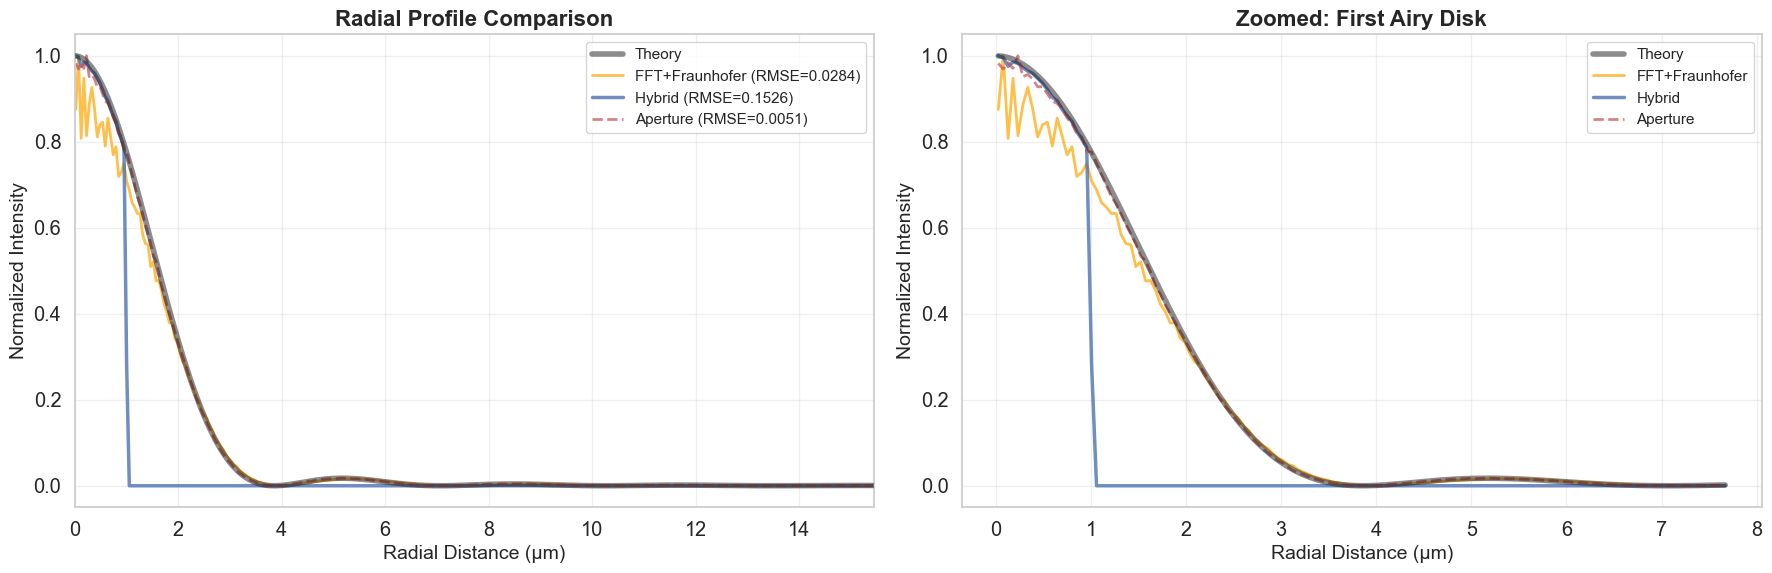

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Full range
ax = axes[0]
ax.plot(r_centers, airy_theory, 'k-', linewidth=4, alpha=0.5, label='Theory', zorder=10)
ax.plot(r_centers, intensity_fft, 'orange', linewidth=2, alpha=0.7, 
        label=f'FFT+Fraunhofer (RMSE={rmse_fft:.4f})')
ax.plot(r_centers, intensity_hybrid, 'b-', linewidth=2.5, alpha=0.8, 
        label=f'Hybrid (RMSE={rmse_hybrid:.4f})')
ax.plot(r_centers, intensity_aperture, 'r--', linewidth=2, alpha=0.7, 
        label=f'Aperture (RMSE={rmse_aperture:.4f})')
ax.set_xlabel('Radial Distance (μm)', fontsize=14)
ax.set_ylabel('Normalized Intensity', fontsize=14)
ax.set_title('Radial Profile Comparison', fontsize=16, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, plot_range])

# Zoomed
ax = axes[1]
zoom_range = airy_radius
zoom_mask = r_centers < zoom_range
ax.plot(r_centers[zoom_mask], airy_theory[zoom_mask], 'k-', linewidth=4, alpha=0.5, 
        label='Theory', zorder=10)
ax.plot(r_centers[zoom_mask], intensity_fft[zoom_mask], 'orange', linewidth=2, alpha=0.7, 
        label='FFT+Fraunhofer')
ax.plot(r_centers[zoom_mask], intensity_hybrid[zoom_mask], 'b-', linewidth=2.5, alpha=0.8, 
        label='Hybrid')
ax.plot(r_centers[zoom_mask], intensity_aperture[zoom_mask], 'r--', linewidth=2, alpha=0.7, 
        label='Aperture')
ax.set_xlabel('Radial Distance (μm)', fontsize=14)
ax.set_ylabel('Normalized Intensity', fontsize=14)
ax.set_title('Zoomed: First Airy Disk', fontsize=16, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{output_dir}/hybrid_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Verify K-Space Distribution

The hybrid approach should sample the exact analytical jinc² distribution

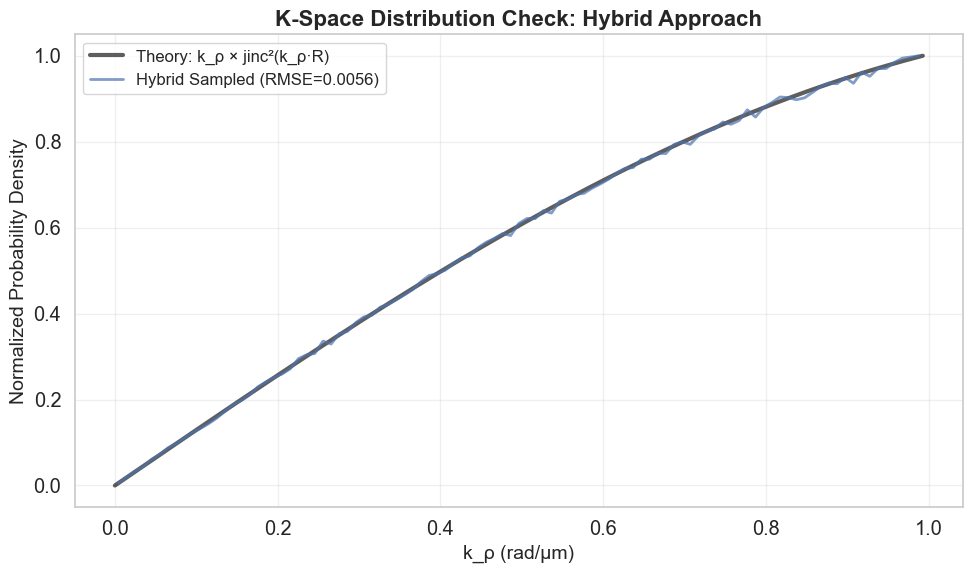


K-space distribution RMSE: 0.005646
  ✓✓✓ EXCELLENT! Perfect analytical sampling!


In [6]:
kx_hybrid, ky_hybrid, kz_hybrid = results_hybrid['k_vectors']
k_rho_hybrid = np.sqrt(kx_hybrid**2 + ky_hybrid**2)

# Theoretical distribution
k_max = sim_hybrid.k_max
aperture_radius = sim_hybrid.aperture_radius
k_theory = np.linspace(0, k_max, 500)
x_arg = k_theory * aperture_radius
jinc_theory = np.ones_like(x_arg)
nonzero = x_arg != 0
jinc_theory[nonzero] = 2 * j1(x_arg[nonzero]) / x_arg[nonzero]
jinc_sq_theory = jinc_theory**2
dist_theory = k_theory * jinc_sq_theory
dist_theory = dist_theory / np.max(dist_theory)

# Histogram of sampled distribution
k_bins = np.linspace(0, k_max, 100)
k_centers = (k_bins[:-1] + k_bins[1:]) / 2
k_hist, _ = np.histogram(k_rho_hybrid, bins=k_bins, density=True)
k_hist = k_hist / np.max(k_hist)

# Compute RMSE
dist_theory_interp = np.interp(k_centers, k_theory, dist_theory)
k_rmse = metrics.rmse(k_hist, dist_theory_interp)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(k_theory, dist_theory, 'k-', linewidth=3, label='Theory: k_ρ × jinc²(k_ρ·R)', alpha=0.7)
ax.plot(k_centers, k_hist, 'b-', linewidth=2, label=f'Hybrid Sampled (RMSE={k_rmse:.4f})', alpha=0.7)
ax.set_xlabel('k_ρ (rad/μm)', fontsize=14)
ax.set_ylabel('Normalized Probability Density', fontsize=14)
ax.set_title('K-Space Distribution Check: Hybrid Approach', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{output_dir}/hybrid_kspace_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nK-space distribution RMSE: {k_rmse:.6f}")
if k_rmse < 0.01:
    print("  ✓✓✓ EXCELLENT! Perfect analytical sampling!")
elif k_rmse < 0.1:
    print("  ✓ GOOD! Much better than FFT discretization.")
else:
    print("  ⚠ Still has sampling error.")

## Summary

In [7]:
print("\n" + "="*70)
print("HYBRID APPROACH RESULTS")
print("="*70)
print("\nMETHOD:")
print("  1. Sample k_ρ from analytical k_ρ × jinc²(k_ρ·R) (rejection sampling)")
print("  2. Sample θ uniformly")
print("  3. Convert to (kx, ky)")
print("  4. Propagate with Fraunhofer: x = (λf/2π) × kx")
print("\nADVANTAGES:")
print("  ✓ No FFT discretization error")
print("  ✓ Correct wavelength dependence")
print("  ✓ Samples exact analytical distribution")
print("\nRESULTS:")
print(f"  FFT + Fraunhofer RMSE:    {rmse_fft:.6f}")
print(f"  Hybrid RMSE:              {rmse_hybrid:.6f}")
print(f"  Aperture RMSE:            {rmse_aperture:.6f}")
print(f"\n  K-space RMSE (hybrid):    {k_rmse:.6f}")

if rmse_hybrid < rmse_aperture * 1.5:
    print("\n  ✓✓✓ SUCCESS! Hybrid approach matches aperture method!")
    print("  Angular spectrum method is now working!")
elif rmse_hybrid < rmse_fft:
    print(f"\n  ✓ IMPROVED! Hybrid is {rmse_fft/rmse_hybrid:.1f}x better than FFT")
    print("  But still room for improvement.")
else:
    print("\n  ⚠ Hybrid is not better than FFT - investigate issue.")
print("="*70)


HYBRID APPROACH RESULTS

METHOD:
  1. Sample k_ρ from analytical k_ρ × jinc²(k_ρ·R) (rejection sampling)
  2. Sample θ uniformly
  3. Convert to (kx, ky)
  4. Propagate with Fraunhofer: x = (λf/2π) × kx

ADVANTAGES:
  ✓ No FFT discretization error
  ✓ Correct wavelength dependence
  ✓ Samples exact analytical distribution

RESULTS:
  FFT + Fraunhofer RMSE:    0.028399
  Hybrid RMSE:              0.152586
  Aperture RMSE:            0.005100

  K-space RMSE (hybrid):    0.005646

  ⚠ Hybrid is not better than FFT - investigate issue.
